In [46]:
import pandas as pd
import spacy
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
fake_data = pd.read_csv('fake_news_data.csv')
fake_data.head(20)
fake_news = fake_data[['text', 'fake_or   _factual']]
fake_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             198 non-null    object
 1   fake_or_factual  198 non-null    object
dtypes: object(2)
memory usage: 3.2+ KB


POS TAGGING

In [8]:
nlp = spacy.load('en_core_web_sm')
fake_news_df = fake_data[fake_data['fake_or_factual'] == 'Fake News']
factual_news_df = fake_data[fake_data['fake_or_factual'] == 'Factual News']

fake_spacy_doc = list(nlp.pipe(fake_news_df['text']))
factual_spacy_doc = list(nlp.pipe(factual_news_df['text']))

In [9]:
fake_tags = []

for row_id, token in enumerate(fake_spacy_doc): 
    for doc in token:
        fake_tags.append(
            {
                "row_id": row_id,
                "token": doc.text,
                "pos_tags": doc.pos_,
                "ner" : doc.ent_type_
            }
        )

fake_tags_df = pd.DataFrame(fake_tags)

In [10]:
fake_tags_df[fake_tags_df['pos_tags'] == "NOUN"].groupby(['token']).size().sort_values(ascending=False)

token
people        77
t             65
president     58
women         55
time          52
              ..
motives        1
motion         1
dispatches     1
mosque         1
#              1
Length: 2586, dtype: int64

In [11]:
fake_tags_df[fake_tags_df['pos_tags'] == "VERB"].groupby(['token']).size().sort_values(ascending=False)

token
s           147
said        144
have         76
know         54
told         49
           ... 
free          1
freak         1
fracking      1
foul          1
yelling       1
Length: 1817, dtype: int64

In [12]:
factual_tags = []

for row_id, token in enumerate(factual_spacy_doc): 
    for doc in token:
        factual_tags.append(
            {
                "row_id": row_id,
                "token": doc.text,
                "pos_tags": doc.pos_,
                "ner" : doc.ent_type_
            }
        )

factual_tags_df = pd.DataFrame(factual_tags)

In [13]:
factual_tags_df[factual_tags_df['pos_tags'] == "NOUN"].groupby(['token']).size().sort_values(ascending=False)

token
government        71
year              64
state             57
bill              55
administration    51
                  ..
appearances        1
.                  1
jewelry            1
jet                1
’s                 1
Length: 2179, dtype: int64

In [14]:
factual_tags_df[factual_tags_df['pos_tags'] == "VERB"].groupby(['token']).size().sort_values(ascending=False)

token
said         451
told          55
have          43
’s            35
including     33
            ... 
operating      1
demonize       1
opposed        1
opposes        1
isolating      1
Length: 1539, dtype: int64

PLOTTING MY FINDINGS

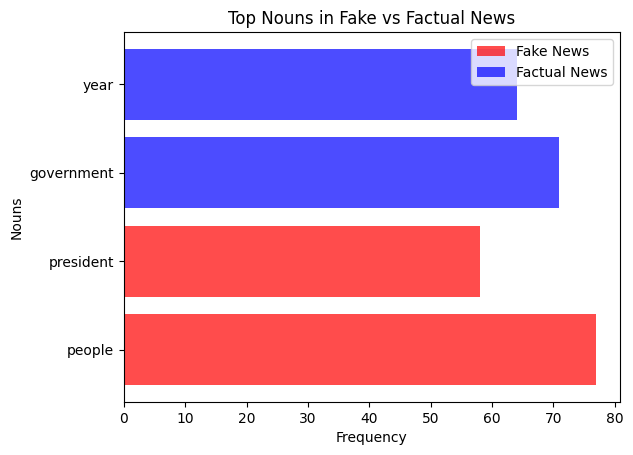

In [15]:
fake_nouns = {'people': 77, 'president': 58}
factual_nouns = {'government': 71, 'year': 64}

fake_verbs = {'said_fake': 144, 'have': 76}
factual_verbs = {'said_fact': 451, 'told': 55}

plt.barh(fake_nouns.keys(), fake_nouns.values(), color='red', alpha=0.7, label='Fake News')
plt.barh(factual_nouns.keys(), factual_nouns.values(), color='blue', alpha=0.7, label='Factual News')
plt.title('Top Nouns in Fake vs Factual News')
plt.xlabel('Frequency')
plt.ylabel('Nouns')
plt.legend()
plt.show()

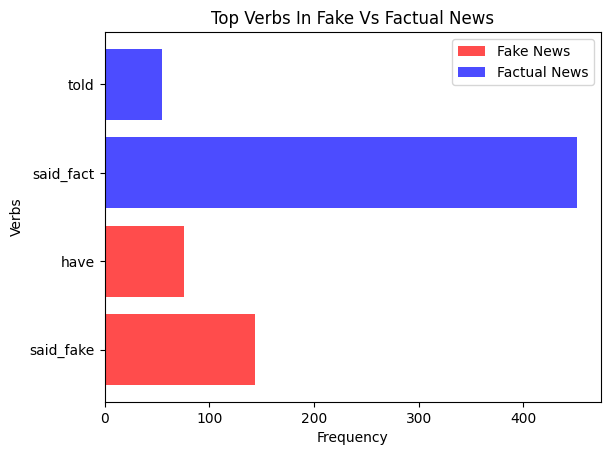

In [16]:
plt.barh(fake_verbs.keys(), fake_verbs.values(), color = 'red', label = 'Fake News', alpha = 0.7)
plt.barh(factual_verbs.keys(), factual_verbs.values(), color = 'blue', label = 'Factual News', alpha = 0.7)
plt.xlabel('Frequency')
plt.ylabel('Verbs')
plt.title('Top Verbs In Fake Vs Factual News')
plt.legend()

TEXT PRE-PROCESSING

In [20]:
fake_news_copy = fake_news.copy()

#lowercasing text
fake_news_copy['lowercased'] = fake_news_copy['text'].apply(lambda x: x.lower())

#removing stop words
en_stopwords = stopwords.words('english')
fake_news_copy['no_stopwords'] = fake_news_copy['lowercased'].apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))

#removing punctuations
fake_news_copy['no_punct'] = fake_news_copy['no_stopwords'].apply(lambda x: re.sub(r"[^\w\s]", "", x))

#tokenization
fake_news_copy['tokenized'] = fake_news_copy['no_punct'].apply(lambda x: word_tokenize(x))

#lemmattize
lem = WordNetLemmatizer()
fake_news_copy['lemmatized'] = fake_news_copy['tokenized'].apply(lambda x: [lem.lemmatize(token) for token in x])

# fake_news_copy.head()
print(en_stopwords)


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

SENTIMENT ANALYSIS

In [18]:
vader = SentimentIntensityAnalyzer()
fake_news_copy['sentiment-scores'] = fake_news_copy['text'].apply(lambda x: vader.polarity_scores(x)['compound'])
fake_news_copy.head()

bins = [-1, -0.1, 0.1, 1]
labels = ['negative', 'neutral', 'positive']

fake_news_copy['sentiment-label'] = pd.cut(fake_news_copy['sentiment-scores'], bins=bins, labels=labels)
fake_news_copy.head()

,text,fake_or_factual,lowercased,no_stopwords,no_punct,tokenized,lemmatized,sentiment-scores,sentiment-label
0,There are two small problems with your analogy...,Fake News,there are two small problems with your analogy...,two small problems analogy susan jesus muslim ...,two small problems analogy susan jesus muslim ...,"[two, small, problems, analogy, susan, jesus, ...","[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Buried in Trump s bonkers interview with New Y...,Fake News,buried in trump s bonkers interview with new y...,buried trump bonkers interview new york times ...,buried trump bonkers interview new york times ...,"[buried, trump, bonkers, interview, new, york,...","[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,"Women make up over 50 percent of this country,...",Fake News,"women make up over 50 percent of this country,...","women make 50 percent country, grossly underre...",women make 50 percent country grossly underrep...,"[women, make, 50, percent, country, grossly, u...","[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,WASHINGTON (Reuters) - U.S. Defense Secretary ...,Factual News,washington (reuters) - u.s. defense secretary ...,washington (reuters) - u.s. defense secretary ...,washington reuters us defense secretary jim m...,"[washington, reuters, us, defense, secretary, ...","[washington, reuters, u, defense, secretary, j...",-0.3400,negative
4,BELFAST (Reuters) - Northern Ireland s politic...,Factual News,belfast (reuters) - northern ireland s politic...,belfast (reuters) - northern ireland political...,belfast reuters northern ireland political pa...,"[belfast, reuters, northern, ireland, politica...","[belfast, reuters, northern, ireland, politica...",0.8590,positive


TEXT CLASSIFICATION

In [32]:
bow_data = fake_news_copy['lemmatized'].apply(lambda x: " ".join(x))
bow_init = CountVectorizer(
    ngram_range= (1, 2),
    min_df= 5,
    max_features= 5000
)
bow_dict = bow_init.fit_transform(bow_data)

bow = pd.DataFrame(bow_dict.toarray(), columns=bow_init.get_feature_names_out())
bow
y = fake_news_copy['fake_or_factual']

x_train, x_test, y_train, y_test = train_test_split(bow, y, random_state=42, test_size=0.3)

lr = LogisticRegression(random_state=42).fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
accuracy_score(y_test, y_pred_lr)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.88      0.91      0.89        32
   Fake News       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [35]:
tfidf_data = fake_news_copy['lemmatized'].apply(lambda x: " ".join(x))
tfidf_init = TfidfVectorizer(
    ngram_range= (1, 2),
    min_df= 5,
    max_features= 5000
)
tfidf_dict = tfidf_init.fit_transform(tfidf_data)

tfidf = pd.DataFrame(tfidf_dict.toarray(), columns=tfidf_init.get_feature_names_out())
tfidf
y = fake_news_copy['fake_or_factual']

x_train, x_test, y_train, y_test = train_test_split(tfidf, y, random_state=42, test_size=0.3)

lr = LogisticRegression(random_state=42).fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
accuracy_score(y_test, y_pred_lr)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.91      0.91      0.91        32
   Fake News       0.89      0.89      0.89        28

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In [48]:
bow_data = fake_news_copy['lemmatized'].apply(lambda x: " ".join(x))
bow_init = CountVectorizer(
    ngram_range= (1, 2),
    min_df= 5,
    max_features= 5000
)
bow_dict = bow_init.fit_transform(bow_data)

bow = pd.DataFrame(bow_dict.toarray(), columns=bow_init.get_feature_names_out())
bow
y = fake_news_copy['fake_or_factual']

x_train, x_test, y_train, y_test = train_test_split(bow, y, random_state=42, test_size=0.3)

svm = SGDClassifier(random_state=42, class_weight='balanced').fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
accuracy_score(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.83      0.94      0.88        32
   Fake News       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



In [47]:
tfidf_data = fake_news_copy['lemmatized'].apply(lambda x: " ".join(x))
tfidf_init = TfidfVectorizer(
    ngram_range= (1, 2),
    min_df= 5,
    max_features= 5000
)
tfidf_dict = tfidf_init.fit_transform(tfidf_data)

tfidf = pd.DataFrame(tfidf_dict.toarray(), columns=tfidf_init.get_feature_names_out())
tfidf
y = fake_news_copy['fake_or_factual']

x_train, x_test, y_train, y_test = train_test_split(tfidf, y, random_state=42, test_size=0.3)

svm = SGDClassifier(random_state=42, class_weight='balanced').fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
accuracy_score(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.96      0.78      0.86        32
   Fake News       0.79      0.96      0.87        28

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60

